In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Kanti\Downloads\Daily Household Transactions.csv")
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20-09-2018 12:04,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20-09-2018 12:03,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19-09-2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17-09-2018 23:41,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16-09-2018 17:15,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [2]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


(2461, 8)

In [3]:
df.isnull().sum()

Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

In [4]:
df = df.drop_duplicates()

In [5]:
df["Subcategory"] = df["Subcategory"].fillna(df["Subcategory"].mode()[0])
df["Note"] = df["Note"].fillna(df["Note"].mode()[0])

In [6]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday

In [8]:
df = df.dropna(subset=["Date"])

In [9]:
for col in df.select_dtypes(include = "object").columns:
    df[col] = df[col].str.strip()

Date
2015-01-13 18:52:00    510.0
2015-01-14 12:42:00    760.0
2015-01-14 15:35:00    120.0
2015-01-14 23:38:00     13.0
2015-01-15 18:23:00    110.0
Name: Amount, dtype: float64


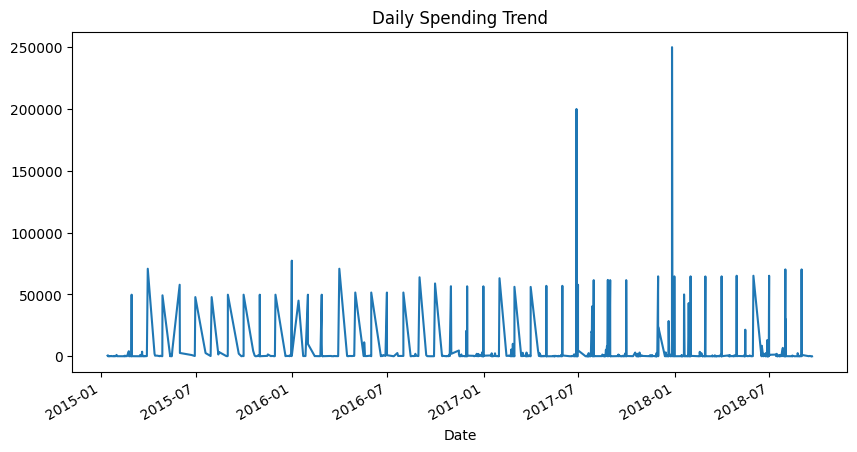

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
daily_spending = df.groupby("Date")["Amount"].sum()
print(daily_spending.head())
daily_spending.plot(figsize=(10,5))
plt.title("Daily Spending Trend")
plt.show()

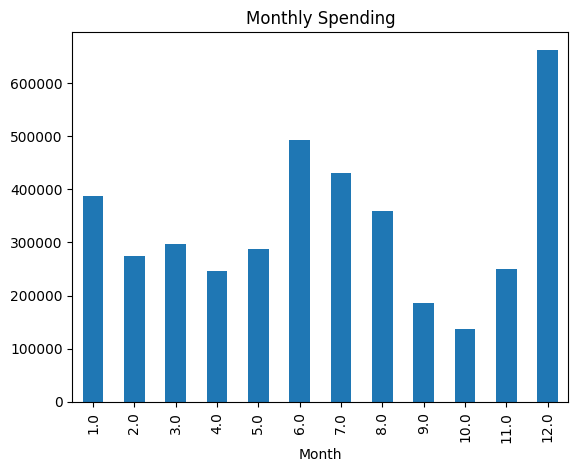

In [11]:
monthly = df.groupby("Month")["Amount"].sum()

monthly.plot(kind="bar")
plt.title("Monthly Spending")
plt.show()

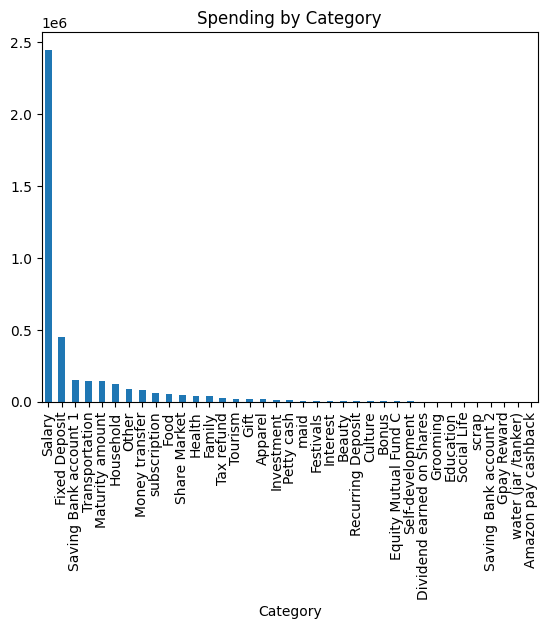

In [12]:
category = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

category.plot(kind="bar")
plt.title("Spending by Category")
plt.show()

In [13]:
top_expense = df.sort_values(by="Amount", ascending=False).head(10)
print(top_expense)

                    Date                   Mode               Category  \
687  2017-12-26 21:55:00  Saving Bank account 1          Fixed Deposit   
1225 2017-06-27 10:00:00  Saving Bank account 1          Fixed Deposit   
688  2017-12-26 21:50:00          Fixed Deposit  Saving Bank account 1   
2061 2015-12-31 16:56:00  Saving Bank account 1                 Salary   
2256 2015-03-31 13:00:00  Saving Bank account 1                 Salary   
1997 2016-03-31 10:25:00  Saving Bank account 1                 Salary   
105  2018-07-31 09:05:00  Saving Bank account 1                 Salary   
33   2018-08-31 09:27:00  Saving Bank account 1                 Salary   
323  2018-04-29 09:36:00  Saving Bank account 1                 Salary   
250  2018-05-31 08:47:00  Saving Bank account 1                 Salary   

     Subcategory                       Note    Amount Income/Expense Currency  \
687         Milk                  milk 1lit  250000.0   Transfer-Out      INR   
1225        Milk  New F

In [14]:
features = ["Year", "Month", "Day", "Weekday", "Category"]

df_model = df[features + ["Amount"]]

In [15]:
df_model = pd.get_dummies(df_model, columns=["Category"], drop_first=True)

In [16]:
X = df_model.drop(columns=["Amount"])
y = df_model["Amount"]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

In [18]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=45
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = mean_squared_error(y_test, y_pred)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:",np.sqrt(rmse))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 823.0649156535757
RMSE: 3383.361713811103
R2 Score: 0.8562361387927311


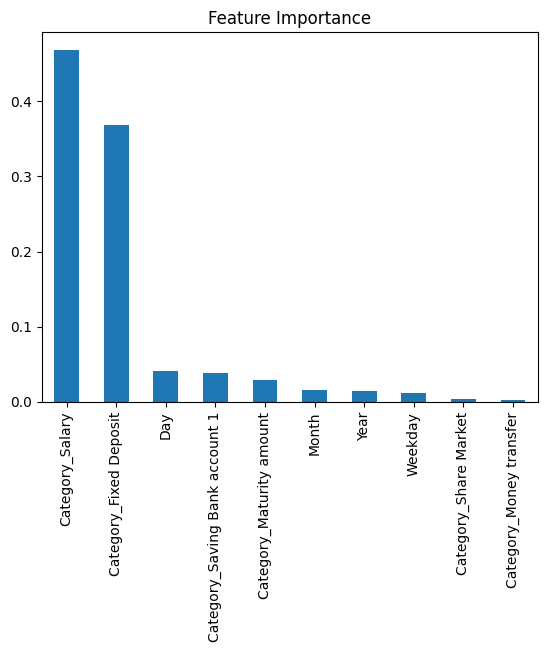

In [21]:

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

In [22]:
future_dates = pd.date_range(start=df["Date"].max(), periods=7)
future_df = pd.DataFrame({
    "Year": future_dates.year,
    "Month": future_dates.month,
    "Day": future_dates.day,
    "Weekday": future_dates.weekday
})

future_df = pd.get_dummies(future_df)
future_df = future_df.reindex(columns=X.columns, fill_value=0)
future_pred = model.predict(future_df)

print(future_pred)

[457.64244108 414.19709144 433.20051482 378.9574408  379.56385376
 456.30457571 528.78136037]
